# Appendix Figure: Annotation Stats (annotation_stats.pdf)

Bar chart showing the ratio of LLM-supported TKGU operations to all TKGU operations,
for both the complete dataset and the subsampled test set.

This figure depends on **dataset-level GT statistics** (not model predictions),
so it is not affected by the `score_empty_predictions_as_zero` fix.

**Data sources:**
- Subsampled test set: loaded from the refactored `WikiEvalResult` pkl
- Complete dataset: to be produced by running the evaluation pipeline on the full
  dataset with `models_to_evaluate: []` and `metrics_to_calculate: {}`.
  Until then, the old pipeline pkl can be used as a temporary bridge.

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

# src/ is 3 levels up from src/stats/dataset/
sys.path.insert(0, os.path.join(os.path.abspath('../../..'), 'src'))

from stats.evaluation.load_results import load_from_wiki_eval_result

In [2]:
# --- CONFIGURE THIS ---

# Subsampled test set (refactored pkl)
SUBSAMPLED_PKL = '/path/to/storage/emerge/output/experiments/s0x_evaluate_predictions/20260217_submitted_icml_fixed/wiki_eval_result.pkl'

# Complete dataset (old pipeline pkl — only df_preds_gt_cie is needed)
COMPLETE_DATASET_PKL = '/path/to/storage/emerge/output/experiments/dataset_stats_pkls/20260124_all_dataset_no_models_v13_all/df_wiki_predictions_and_gt_cie.pkl'

SAVE_DIR = '/path/to/storage/emerge/output/figures/'

In [3]:
# Load subsampled test set from refactored pkl
(_, _, df_preds_gt_cie_sub, _, _, _) = load_from_wiki_eval_result(SUBSAMPLED_PKL)
df_preds_gt_cie_sub = df_preds_gt_cie_sub[df_preds_gt_cie_sub['triple_type'] == 'in-dataset']
print(f'Subsampled GT shape: {df_preds_gt_cie_sub.shape}')

# Load complete dataset from old pipeline pkl
df_preds_gt_cie_all = pd.read_pickle(COMPLETE_DATASET_PKL)
print(f'Complete dataset GT shape: {df_preds_gt_cie_all.shape}')

Subsampled GT shape: (36245, 24)


Complete dataset GT shape: (3887196, 24)


In [4]:
# Store in dict for the plotting function
dict_stats = {
    'complete_dataset': {'df_preds_gt_cie': df_preds_gt_cie_all},
    'subsampled_dataset': {'df_preds_gt_cie': df_preds_gt_cie_sub},
}

# Assessor mappings per dataset
# Note: complete dataset uses different assessor names (8B for assertion)
# than the subsampled set (405B for both)
df_llm_assessors = {
    'complete_dataset': {
        'triple_assertion': 'Meta-Llama-3.1-8B_triple_assertion',
        'triple_deprecation': 'Meta-Llama-3.1-405B_triple_deprecation'
    },
    'subsampled_dataset': {
        # Refactored pipeline: assessor stored WITHOUT prompt_type suffix
        'triple_assertion': 'Meta-Llama-3.1-405B_prompt_v1',
        'triple_deprecation': 'Meta-Llama-3.1-405B_prompt_v1'
    }
}

In [5]:
# --- TKGU label mapping ---
tkgu_type_to_label = {
    "x-triples": "E",
    "d-triples": "D",
    "e-triples": "A",
    "ee-triples": "M+A",
    "ee-kg-triples": "I",
}
preferred_order_labels = ["E", "I", "A", "M+A", "D"]

title_to_display = {
    'complete_dataset': 'Complete dataset',
    'subsampled_dataset': 'Subsampled test set'
}

colors = ['#1b9e77', '#d95f02']  # All, Supported


def normalize_tkgu_label(v):
    s = str(v).strip().lower()
    return tkgu_type_to_label.get(s, str(v).strip())


def summarize_preds_df(df_preds_gt_cie, assessor_map):
    d = df_preds_gt_cie.copy()
    d["_tkgu_label"] = d["tkgu_type"].map(normalize_tkgu_label)

    expected_assessor = d["prompt_type"].map(assessor_map)
    mask_expected = (d["llm_assessor"].astype(str) == expected_assessor.astype(str))
    mask_bool = d["llm_assessor_result"].apply(lambda x: isinstance(x, (bool, np.bool_)))

    d_eval = d[mask_expected & mask_bool].copy()

    matched = (
        d_eval.groupby("_tkgu_label", dropna=False).size()
        .rename("Matched").reset_index()
        .rename(columns={"_tkgu_label": "TKGU operation"})
    )
    supported = (
        d_eval.groupby("_tkgu_label", dropna=False)["llm_assessor_result"]
        .sum().rename("LLM-checked").reset_index()
        .rename(columns={"_tkgu_label": "TKGU operation"})
    )

    summary = matched.merge(supported, on="TKGU operation", how="left")
    summary["LLM-checked"] = summary["LLM-checked"].fillna(0).astype(int)

    existing = summary["TKGU operation"].astype(str).tolist()
    unknowns = [x for x in existing if x not in preferred_order_labels]
    full_order = preferred_order_labels + sorted(set(unknowns))
    summary = (
        summary.set_index("TKGU operation")
        .reindex(full_order).dropna(subset=["Matched"]).reset_index()
    )
    return summary

/tmp/ipykernel_2011950/3590948477.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  summary["LLM-checked"] = summary["LLM-checked"].fillna(0).astype(int)
/tmp/ipykernel_2011950/3590948477.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  summary["LLM-checked"] = summary["LLM-checked"].fillna(0).astype(int)


Saved to /path/to/storage/emerge/output/figures/


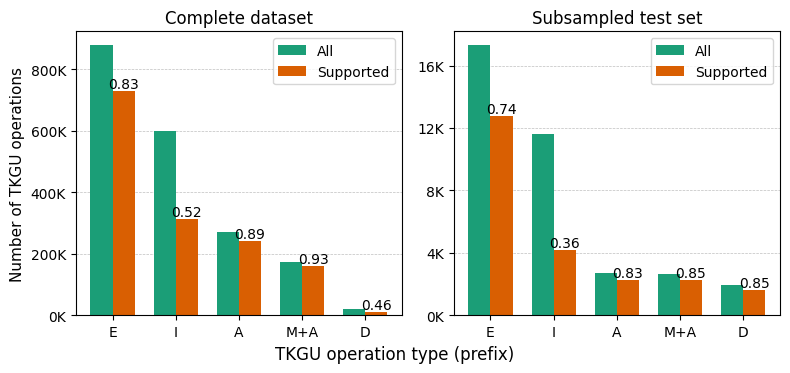

In [6]:
keys_to_plot = ["complete_dataset", "subsampled_dataset"]

n = len(keys_to_plot)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.6), sharey=False)
if n == 1:
    axes = [axes]

for ax, key in zip(axes, keys_to_plot):
    df_preds = dict_stats[key]["df_preds_gt_cie"]
    assessor_map = df_llm_assessors[key]
    summary_df = summarize_preds_df(df_preds, assessor_map)

    x = np.arange(len(summary_df["TKGU operation"]))
    width = 0.35

    bars_all = ax.bar(x - width / 2, summary_df["Matched"], width,
                      label="All", color=colors[0])
    bars_sup = ax.bar(x + width / 2, summary_df["LLM-checked"], width,
                      label="Supported", color=colors[1])

    ax.set_title(title_to_display.get(key, key), fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df["TKGU operation"], rotation=0)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y / 1000)}K"))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.grid(True, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.set_axisbelow(True)

    for i, bar in enumerate(bars_sup):
        matched = int(summary_df["Matched"].iloc[i])
        supported = int(summary_df["LLM-checked"].iloc[i])
        frac = (supported / matched) if matched else 0.0
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{frac:.2f}", ha="center", va="bottom", fontsize=10)

    ax.legend()

axes[0].set_ylabel("Number of TKGU operations", fontsize=11)
fig.text(0.5, 0.00, "TKGU operation type (prefix)", ha="center", va="center", fontsize=12)
plt.tight_layout()

if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)
    fig.savefig(os.path.join(SAVE_DIR, "annotation_stats.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(SAVE_DIR, "annotation_stats.png"), bbox_inches="tight", dpi=300)
    print(f"Saved to {SAVE_DIR}")

plt.show()